Step 1: Install OpenCV

In [1]:
!pip install opencv-python-headless

Step 2: Camera Capture

In [2]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.95):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');

      const capture = document.createElement('button');
      capture.textContent = '📷 Capture Photo';

      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display='block';

      const stream = await navigator.mediaDevices.getUserMedia({video:true});

      document.body.appendChild(div);

      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);

      await new Promise(resolve=>capture.onclick=resolve);

      const canvas=document.createElement('canvas');

      canvas.width=video.videoWidth;

      canvas.height=video.videoHeight;

      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks().forEach(track=>track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg',quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename,'wb') as f:
        f.write(binary)

    return filename

Step 3: Capture an Image

In [14]:
image_path = take_photo()

print("Image saved:", image_path)

<IPython.core.display.Javascript object>

Image saved: photo.jpg


Step 4: Load the Model

In [15]:
from tensorflow import keras

MODEL_PATH = "/content/deepfer_efficientnetb0_best.keras"

model = keras.models.load_model(MODEL_PATH)

print("Model Loaded Successfully!")

Model Loaded Successfully!


Step 5: Detect Face + Predict Emotion

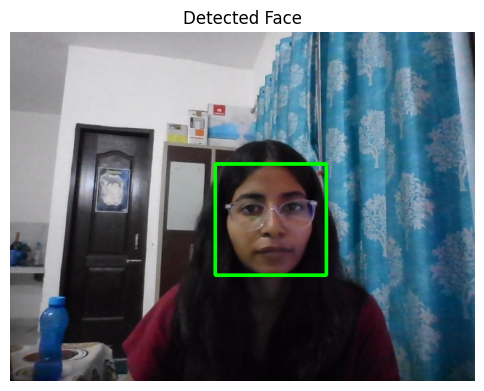

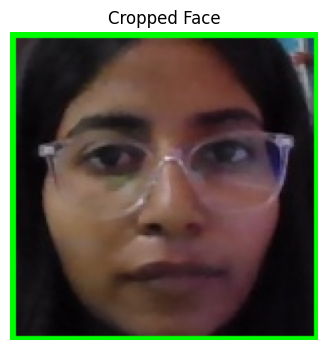


Predicted Emotion : Happy
Confidence : 30.11%

Emotion Probabilities

Angry     : 11.29%
Disgust   : 16.52%
Fear      : 3.96%
Happy     : 30.11%
Neutral   : 20.10%
Sad       : 10.69%
Surprise  : 7.33%


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

# ==========================================================
# CHANGE THIS ONLY IF YOUR MODEL USED ANOTHER INPUT SIZE
# ==========================================================

IMG_SIZE = 96

EMOTION_CLASSES = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# ==========================================================
# Read Image
# ==========================================================

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================================================
# Load Haar Cascade
# ==========================================================

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# ==========================================================
# Detect Face
# ==========================================================

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(80,80)
)

if len(faces)==0:

    print("❌ No face detected!")

else:

    # Take largest face

    x,y,w,h=max(faces,key=lambda f:f[2]*f[3])

    # Draw Rectangle

    cv2.rectangle(
        img_rgb,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        3
    )

    # Crop Face

    face=img_rgb[y:y+h,x:x+w]

    # Display Original

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title("Detected Face")
    plt.axis("off")
    plt.show()

    # Display Cropped Face

    plt.figure(figsize=(4,4))
    plt.imshow(face)
    plt.title("Cropped Face")
    plt.axis("off")
    plt.show()

    # ======================================================
    # Resize
    # ======================================================

    face=cv2.resize(face,(IMG_SIZE,IMG_SIZE)).astype("float32")

    # Preprocess EXACTLY the way the model was trained (EfficientNetB0's own
    # preprocess_input), NOT a plain /255.0 rescale. Using the wrong preprocessing
    # here was why predictions looked wrong (e.g. "neutral" for a happy face) --
    # the pretrained backbone's weights expect this specific input scaling.

    face=effnet_preprocess(face)

    # Add Batch Dimension

    face=np.expand_dims(face,axis=0)

    # ======================================================
    # Predict
    # ======================================================

    prediction=model.predict(face,verbose=0)[0]

    emotion_idx=np.argmax(prediction)

    confidence=prediction[emotion_idx]*100

    print("\n==============================")

    print("Predicted Emotion :",EMOTION_CLASSES[emotion_idx])

    print(f"Confidence : {confidence:.2f}%")

    print("==============================\n")

    print("Emotion Probabilities\n")

    for emotion,prob in zip(EMOTION_CLASSES,prediction):

        print(f"{emotion:<10}: {prob*100:.2f}%")